In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
def visualize(X_grid,X_circle,X_vec,title_txt):
    fig,ax = plt.subplots()

    for i in range(X_grid.shape[0]):
        plt.plot(X_grid[i,:,0],X_grid[i,:,1],'k-',linewidth = 0.5)
    for j in range(X_grid.shape[1]):
        plt.plot(X_grid[:,j,0],X_grid[:,j,1],'k-',linewidth = 0.5)

    colors = plt.cm.hsv(np.linspace(0,1,X_circle.shape[0]))
    for i in range(X_circle.shape[0]):
        plt.plot(X_circle[i,0],X_circle[i,1],'o',color = colors[i],markersize = 5)

    plt.quiver(0,0,X_vec[0,0],X_vec[0,1],angles = 'xy',scale_units = 'xy',scale = 1,color = [0,0.4392,0.7529])
    plt.quiver(0,0,X_vec[1,0],X_vec[1,1],angles = 'xy',scale_units = 'xy',scale = 1,color = [1,0,0])

    plt.axvline(x=0, color='k', zorder=0)  # 绘制 x 轴
    plt.axhline(y=0, color='k', zorder=0)  # 绘制 y 轴
    
    # 设置标签和网格
    plt.ylabel('$x_2$')  # y轴标签
    plt.xlabel('$x_1$')  # x轴标签
    ax.set_aspect(1)  # 设置坐标轴比例 #
    ax.set_xlim([-3, 3])  # x轴范围
    ax.set_ylim([-3, 3])  # y轴范围
    ax.grid(linestyle='--', linewidth=0.15, color=[0.8, 0.8, 0.8])  # 添加网格
    plt.title(title_txt)  # 设置图标题

In [11]:
x_vals = np.arange(-8,8+1)
y_vals = np.arange(-8,8+1)
X1,X2 = np.meshgrid(x_vals,y_vals)
X_grid = np.stack([X1,X2],axis = 2) #会自动新建一个维度

In [12]:
theta = np.linspace(0,2*np.pi,30)
circle_x1 = np.cos(theta)
circle_x2 = np.sin(theta)
X_circle = np.array([circle_x1,circle_x2]).T

In [13]:
X_vec = np.array([[1,0],
                  [0,1]])

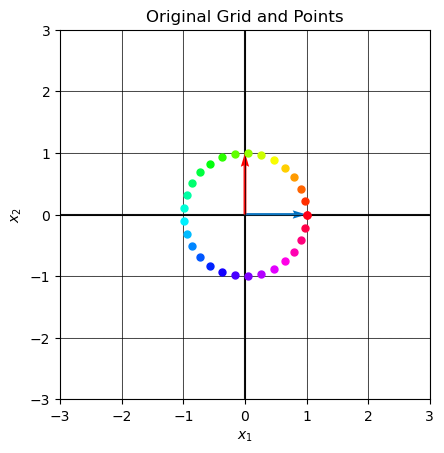

In [15]:
visualize(X_grid,X_circle,X_vec,'Original Grid and Points')

In [16]:
A = np.array([[1.6250,0.6495],
              [0.6495,0.8750]])

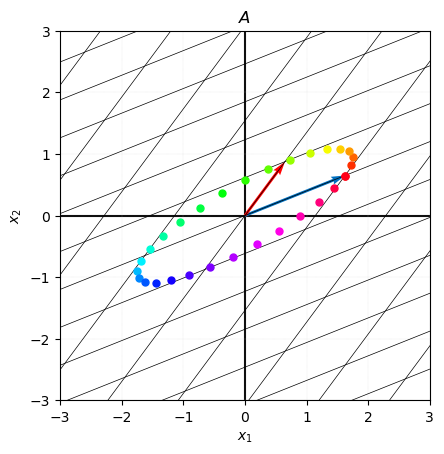

In [17]:
visualize(X_grid @ A.T,
          X_circle @ A.T,
          X_vec @ A.T,
          '$A$')

In [20]:
U,S,V_T = np.linalg.svd(A)
S = np.diag(S)

if U[0,0] < 0: #SVD没有唯一解,但这里是已知这个计算机环境里的U的固定解了,所以只改u1
    U[:,0] = -U[:,0]
    V_T[0,:] = -V_T[0,:]

In [21]:
print('----- U -----')
print(U)
print('----- S -----')
print(S)
print('----- V_T -----')
print(V_T)

----- U -----
[[ 0.86602858 -0.4999945 ]
 [ 0.4999945   0.86602858]]
----- S -----
[[1.9999835 0.       ]
 [0.        0.5000165]]
----- V_T -----
[[ 0.86602858  0.4999945 ]
 [-0.4999945   0.86602858]]


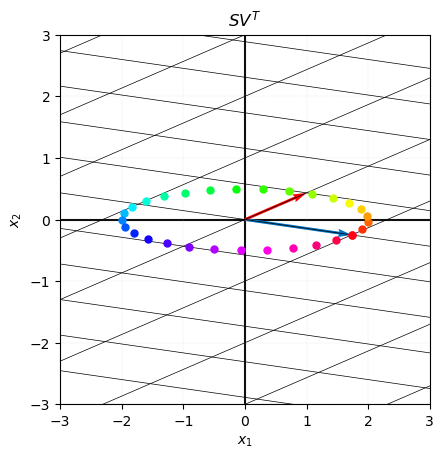

In [23]:
visualize(X_grid @ V_T.T @ S,X_circle @ V_T.T @ S,X_vec @ V_T.T @ S,'$SV^T$')

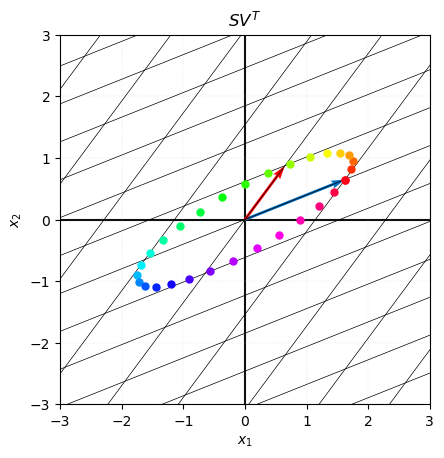

In [24]:
visualize(X_grid @ V_T.T @ S @ U.T,
          X_circle @ V_T.T @ S @ U.T,
          X_vec @ V_T.T @ S @ U.T,
          '$SV^T$')